In [293]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os

In [294]:
data=pd.DataFrame({
    'Name':["A","B","C","D","E","F","F","F"],
    'Age':[15,16,None,15,14,16,16,16],
    'StudyHours':[1,2,3,4,5,2,2,2],
    'City':['Dhaka','Sylhet','Dhaka','Chittagong','Dhaka','Sylhet','Sylhet','Sylhet'],
    'Marks':[30,40,50,60,70,40,40,40],
    'Result':[0,0,1,1,1,0,1,1]
})

In [295]:
#Remove duplicate rows
print(data.duplicated().sum())
data.drop_duplicates()
data.drop_duplicates(subset=['Name','Age','StudyHours','City','Marks','Result'])
data.reset_index(drop=True,inplace=True)
print(data)

1
  Name   Age  StudyHours        City  Marks  Result
0    A  15.0           1       Dhaka     30       0
1    B  16.0           2      Sylhet     40       0
2    C   NaN           3       Dhaka     50       1
3    D  15.0           4  Chittagong     60       1
4    E  14.0           5       Dhaka     70       1
5    F  16.0           2      Sylhet     40       0
6    F  16.0           2      Sylhet     40       1
7    F  16.0           2      Sylhet     40       1


In [296]:
#Handle missing values in Age
print(data['Age'].isnull().sum())
data['Age'].describe()

1


count     7.000000
mean     15.428571
std       0.786796
min      14.000000
25%      15.000000
50%      16.000000
75%      16.000000
max      16.000000
Name: Age, dtype: float64

In [297]:
data['Age']=data['Age'].fillna(data['Age'].median())
print(data.isnull().sum())

Name          0
Age           0
StudyHours    0
City          0
Marks         0
Result        0
dtype: int64


In [298]:
#Find: Mean Age,Median Marks,Standard deviation of StudyHours
col_Age=data['Age']
col_Marks=data['Marks']
col_StudyHours=data['StudyHours']
print("Mean Age:", col_Age.mean())
print("Median Marks:", col_Marks.median())
print("Standard deviation of StudyHours:", col_StudyHours.std())

Mean Age: 15.5
Median Marks: 40.0
Standard deviation of StudyHours: 1.3024701806293193


(array([1., 4., 1., 1., 1.]),
 array([30., 38., 46., 54., 62., 70.]),
 <BarContainer object of 5 artists>)

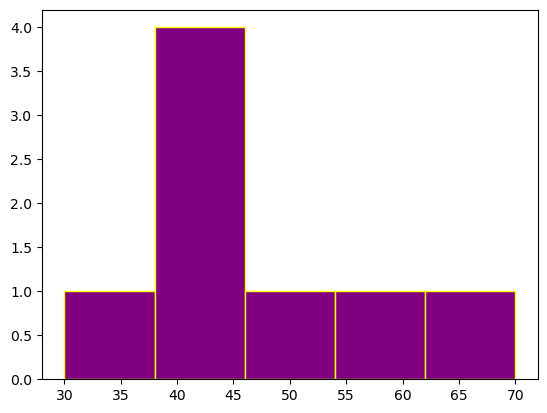

In [299]:
#Show distribution: Histogram of Marks,Boxplot of Age

plt.figure()
plt.hist(data['Marks'],bins=5,color='purple',edgecolor='yellow')

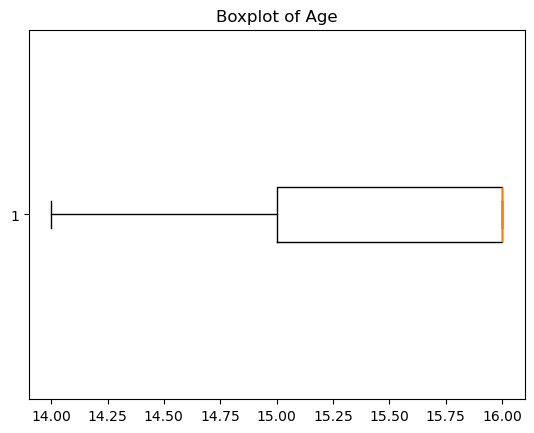

In [300]:
#Boxplot of Age
plt.figure()
plt.boxplot(data['Age'],vert=False)
plt.title('Boxplot of Age')
plt.show()

In [301]:
#Encode City using One-Hot Encoding
encoded_City=pd.get_dummies(data['City'])
print(encoded_City)

   Chittagong  Dhaka  Sylhet
0       False   True   False
1       False  False    True
2       False   True   False
3        True  False   False
4       False   True   False
5       False  False    True
6       False  False    True
7       False  False    True


In [302]:
#Scale: Age,StudyHours
from sklearn.preprocessing import StandardScaler,MinMaxScaler

#StandardScaler
std=StandardScaler()
scaled_Age=std.fit_transform(data[['Age','StudyHours']])
print("Standard Scale Age:\n", scaled_Age)

#MinMaxScaler
mn=MinMaxScaler()
Scaled_StudyHours=mn.fit_transform(data[['StudyHours']])
print("MinMax Scale StudyHours:\n", Scaled_StudyHours)

Standard Scale Age:
 [[-0.70710678 -1.33377186]
 [ 0.70710678 -0.51298918]
 [ 0.70710678  0.30779351]
 [-0.70710678  1.12857619]
 [-2.12132034  1.94935887]
 [ 0.70710678 -0.51298918]
 [ 0.70710678 -0.51298918]
 [ 0.70710678 -0.51298918]]
MinMax Scale StudyHours:
 [[0.  ]
 [0.25]
 [0.5 ]
 [0.75]
 [1.  ]
 [0.25]
 [0.25]
 [0.25]]


In [303]:
#Split data into: 80% train,20% test
from sklearn.model_selection import train_test_split

X=data[['Age','StudyHours','Marks']]
y=data['Result']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
print("X train:\n", X_train)
print("y train:\n", y_train)
print("X test:\n", X_test)
print("y test:\n", y_test)

X train:
     Age  StudyHours  Marks
7  16.0           2     40
2  16.0           3     50
4  14.0           5     70
3  15.0           4     60
6  16.0           2     40
y train:
 7    1
2    1
4    1
3    1
6    1
Name: Result, dtype: int64
X test:
     Age  StudyHours  Marks
1  16.0           2     40
5  16.0           2     40
0  15.0           1     30
y test:
 1    0
5    0
0    0
Name: Result, dtype: int64


In [304]:
#Train 3 models: Logistic Regression,k-NN,Decision Tree
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

#Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

#k-NN
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)
knn_preds = knn_model.predict(X_test)

#Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(1)

In [ ]:
#For each model, calculate: Accuracy,Precision,Recall,F1-score
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

models_preds={
    'LogisticRegression':log_preds,
    'k-NN':knn_preds,
    'Decision Tree':dt_preds
}

for model_name,preds in models_preds.items():
    print(f"==={model_name} Performance===")
    print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
    print(f"Precision: {precision_score(y_test, preds,pos_label=1,zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_test, preds,pos_label=1,zero_division=0):.4f}")
    print(f"F1-Score: {f1_score(y_test, preds,pos_label=1,zero_division=0):.4f}")
    print("-" * 30)

===LogisticRegression Performance===
Accuracy: 0.0000
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
------------------------------
===k-NN Performance===
Accuracy: 0.0000
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
------------------------------
===Decision Tree Performance===
Accuracy: 0.0000
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
------------------------------


In [ ]:
#Predict Marks using: Linear Regression and Evaluate using: MSE